# 1. Business Problem Definition
Objective : predict house sale price based on property characteristics
Problem type : Supervised Learning, Tabular data, Regression
Evaluation Metric : RMSE (Root Mean Squared Error) used to penalize large errors

# 2. Load Data & Basic Inspection
### What to Check :
Shape of dataset    : numbers of row and column
Head of dataset     : first 5 row of the dataset
Info of dataset     : obvious missing values, data types of each columns, and whether SalePrice exists only in training data

In [55]:
import pandas as pd
import numpy as np

In [56]:
df = pd.read_csv('../data/train.csv')

In [57]:
df.shape

(1460, 81)

In [58]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [60]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# 3. EDA

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

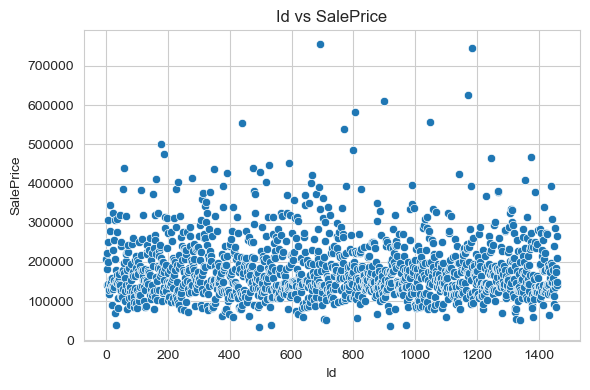

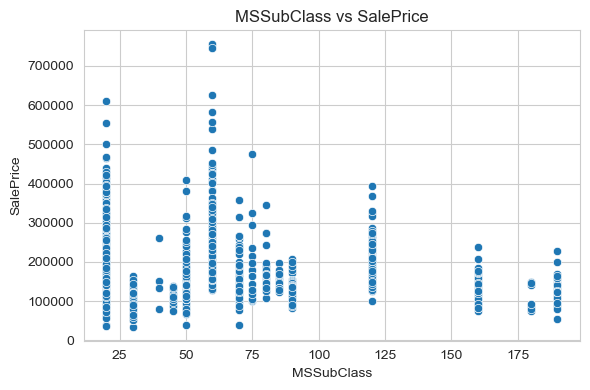

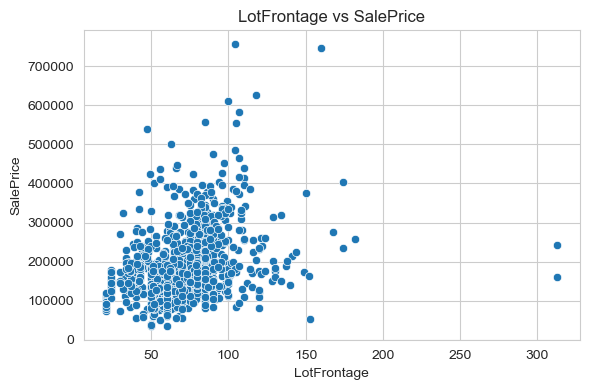

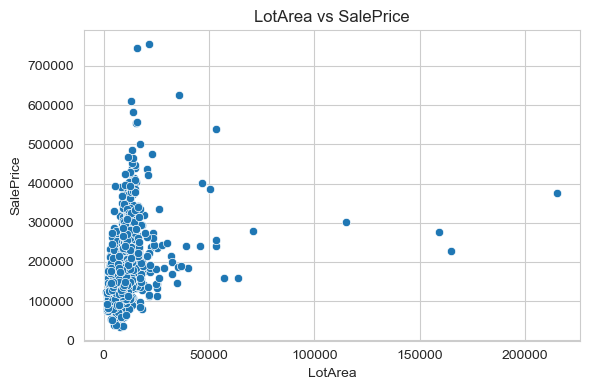

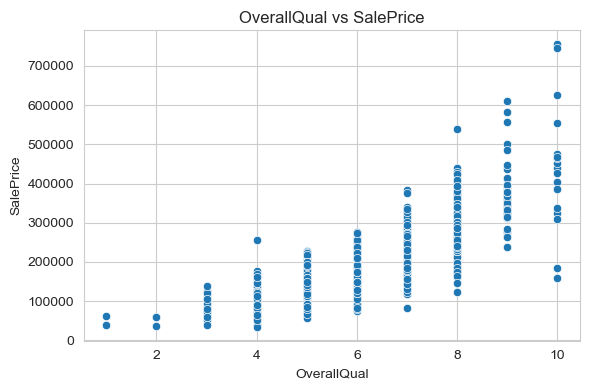

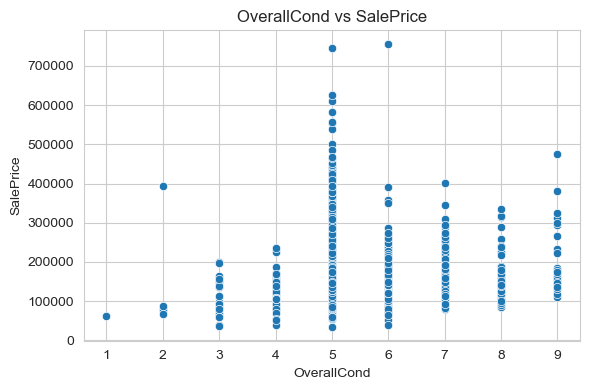

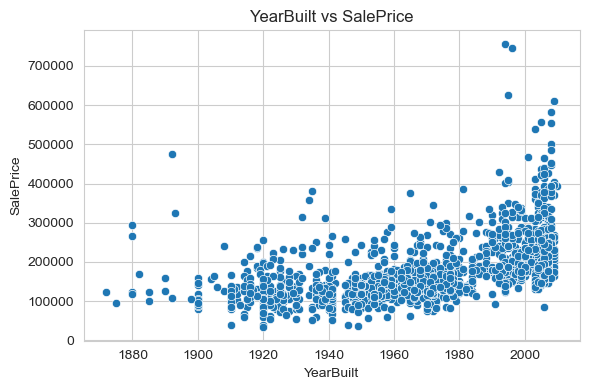

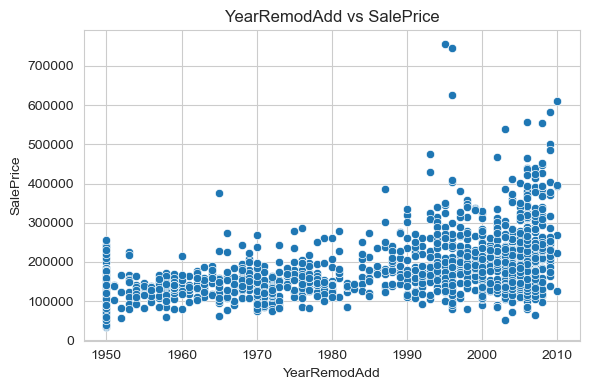

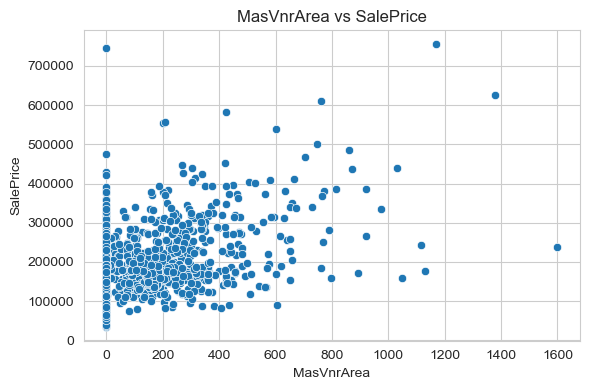

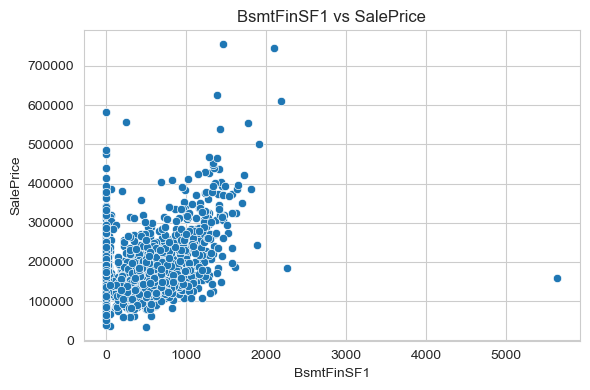

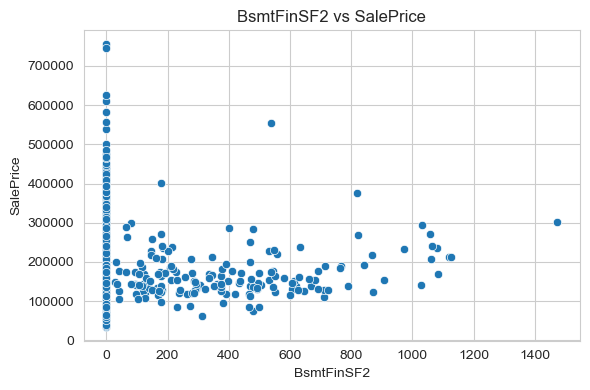

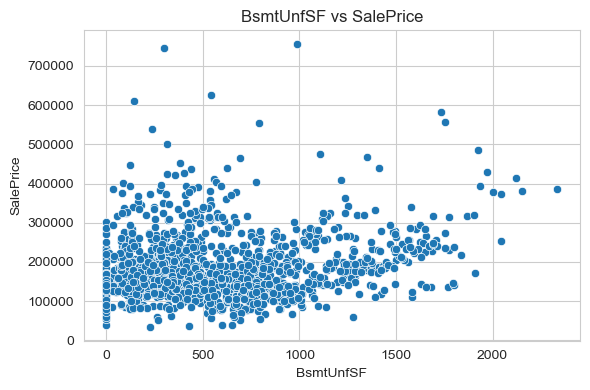

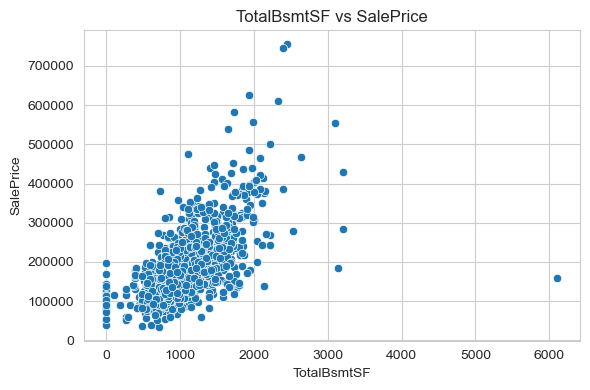

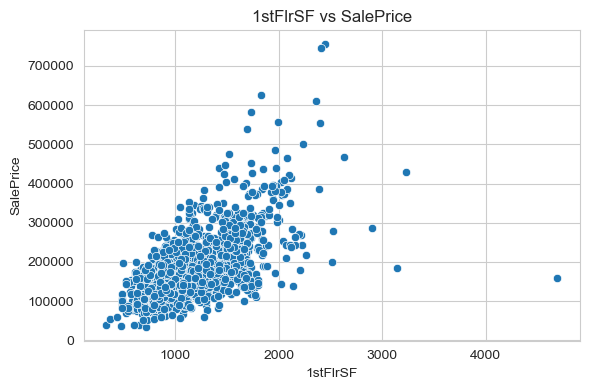

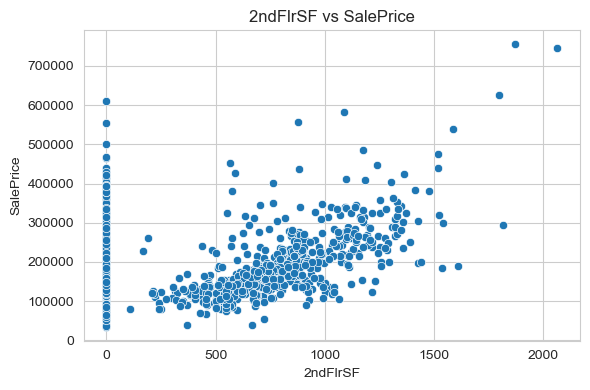

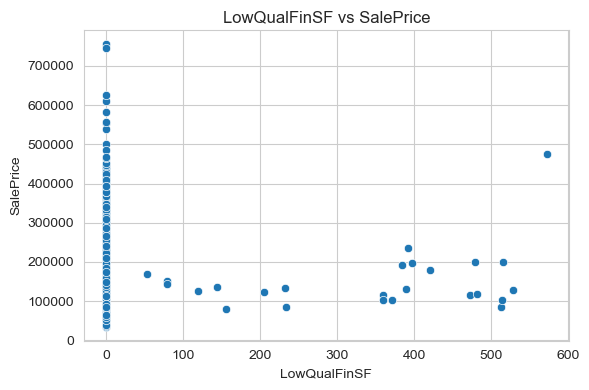

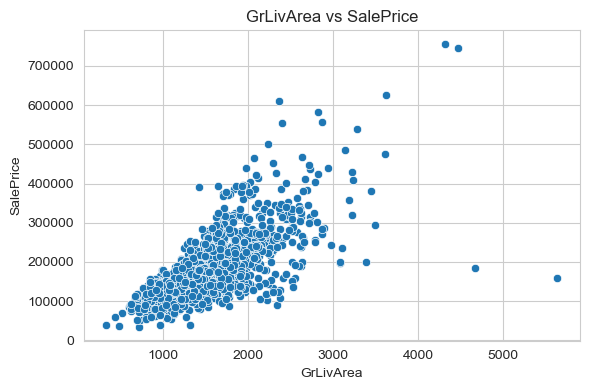

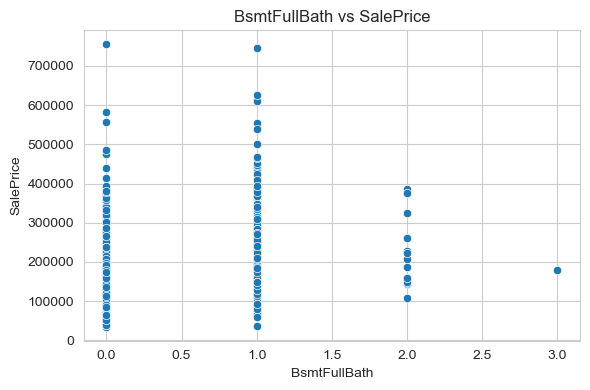

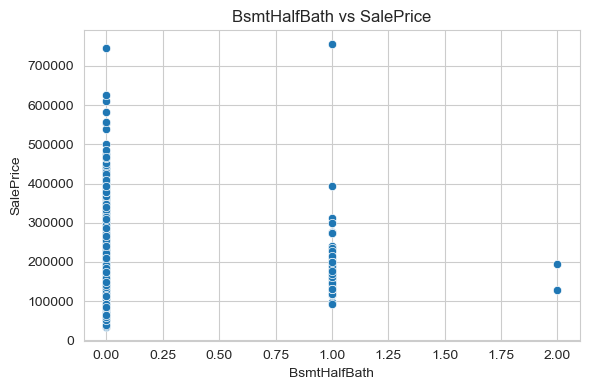

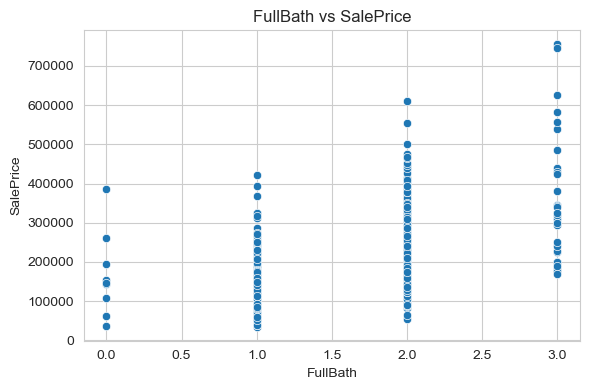

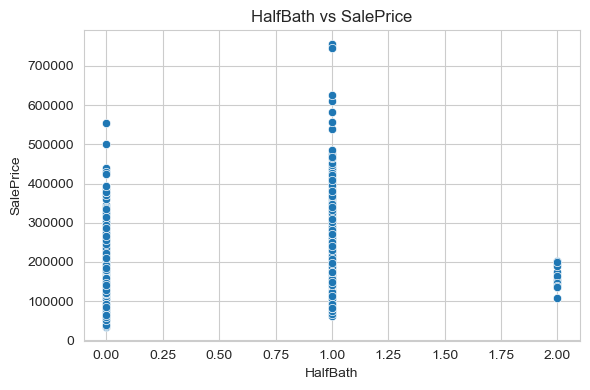

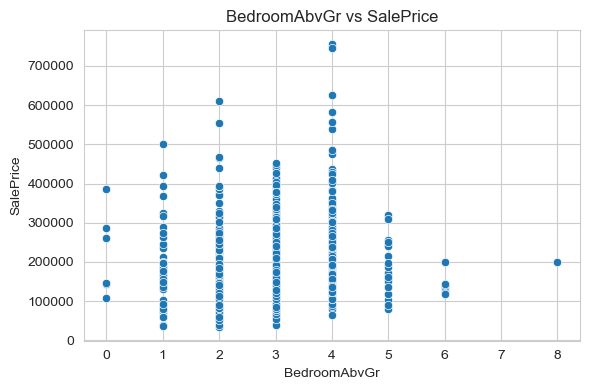

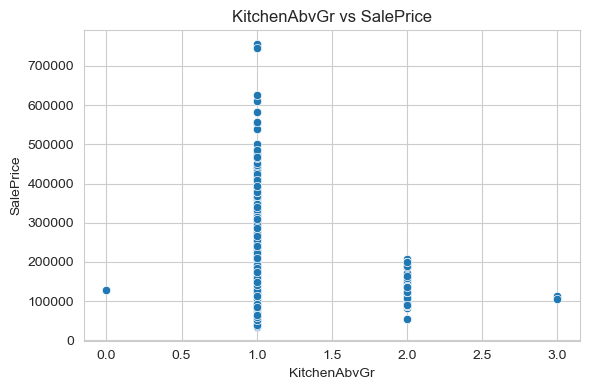

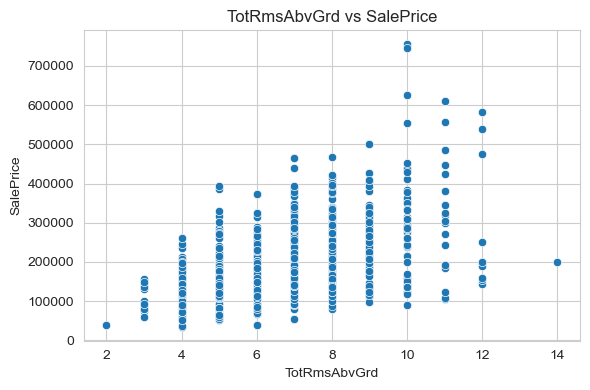

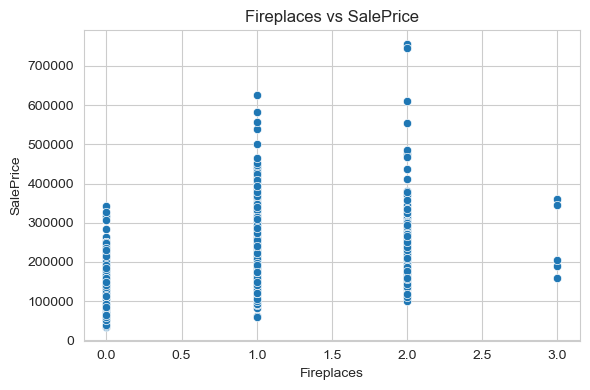

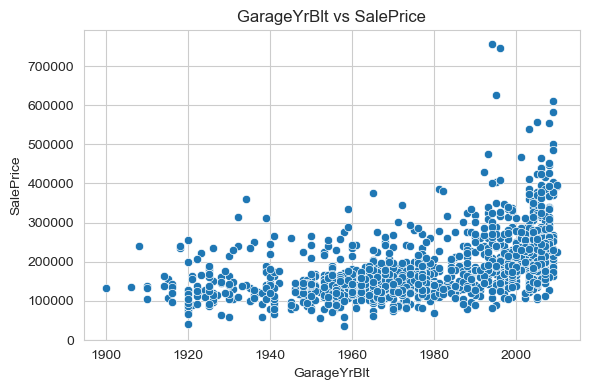

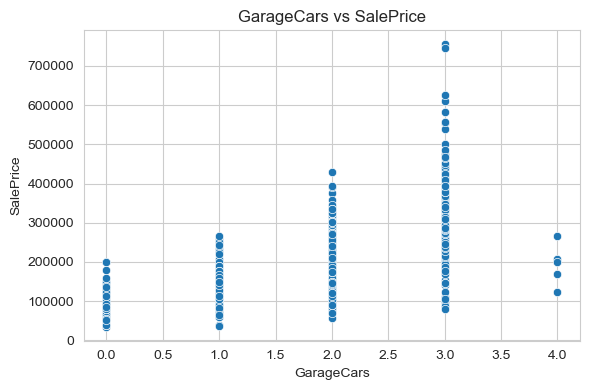

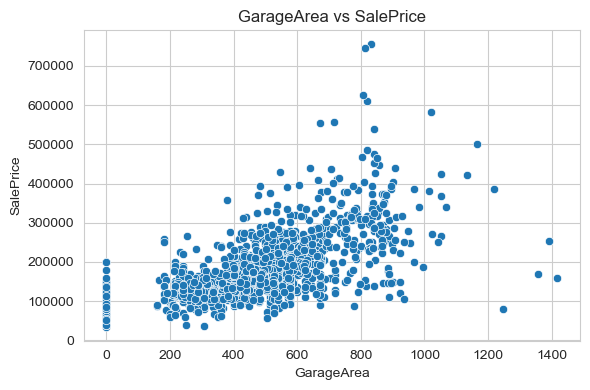

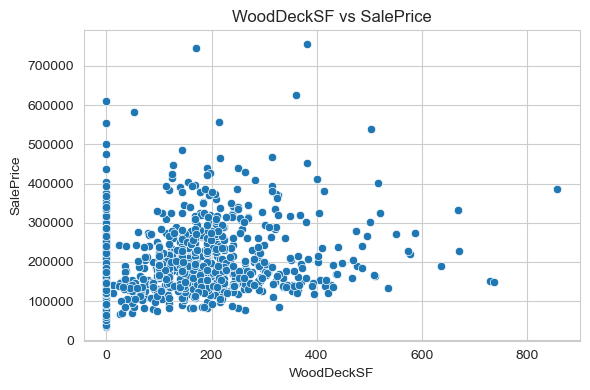

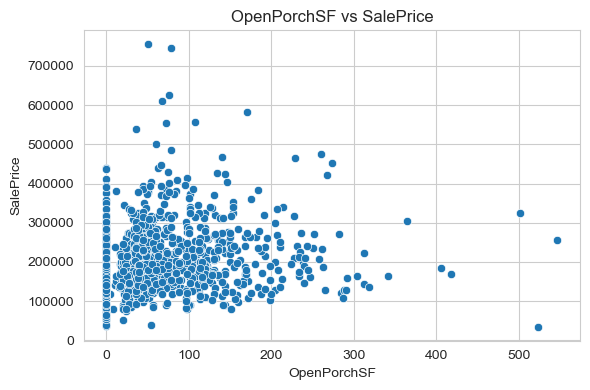

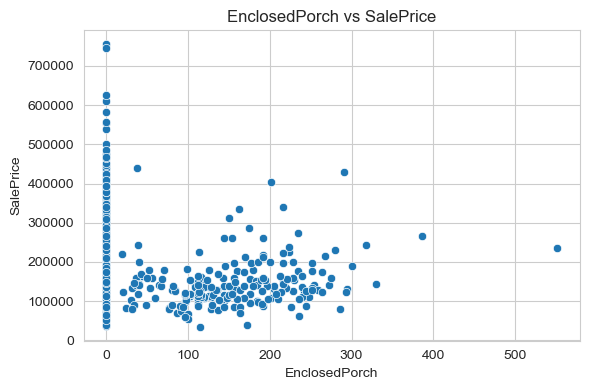

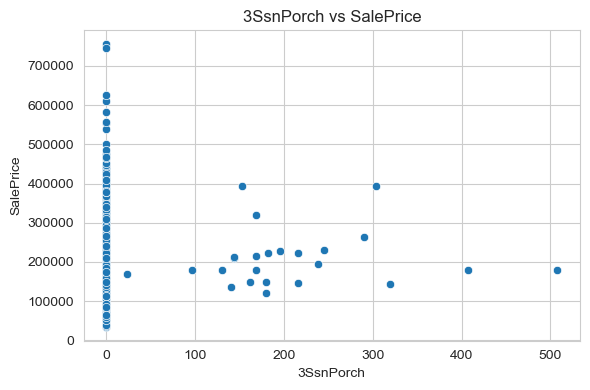

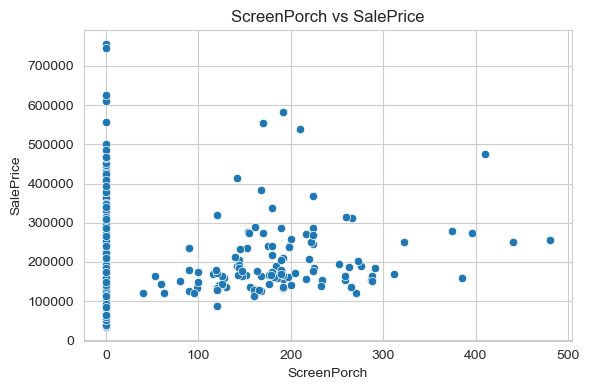

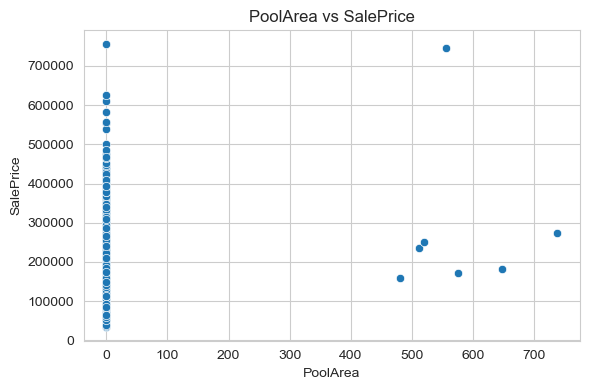

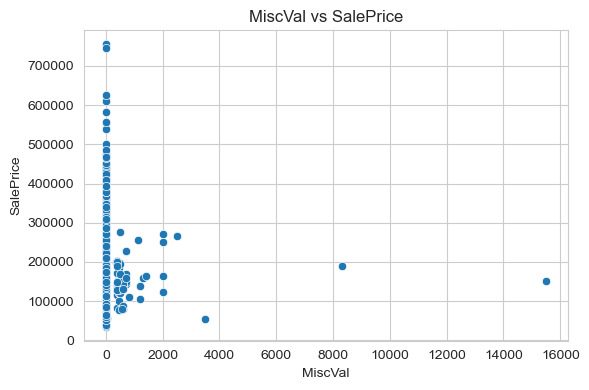

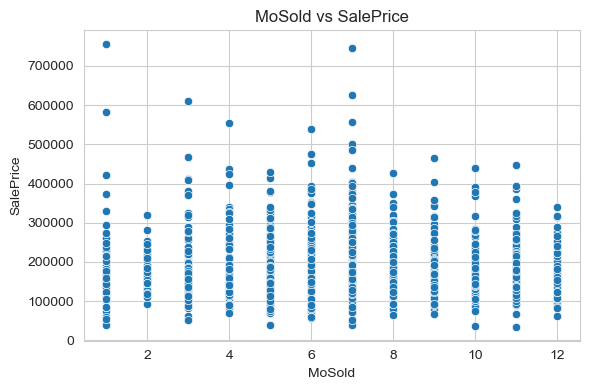

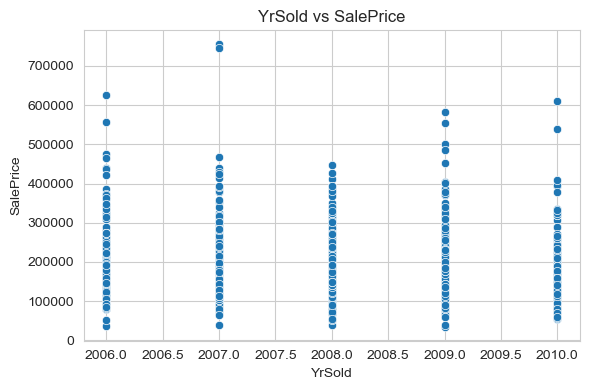

In [63]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    if col != "SalePrice":
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df["SalePrice"])
        plt.title(f"{col} vs SalePrice")
        plt.tight_layout()
        plt.show()

<Axes: >

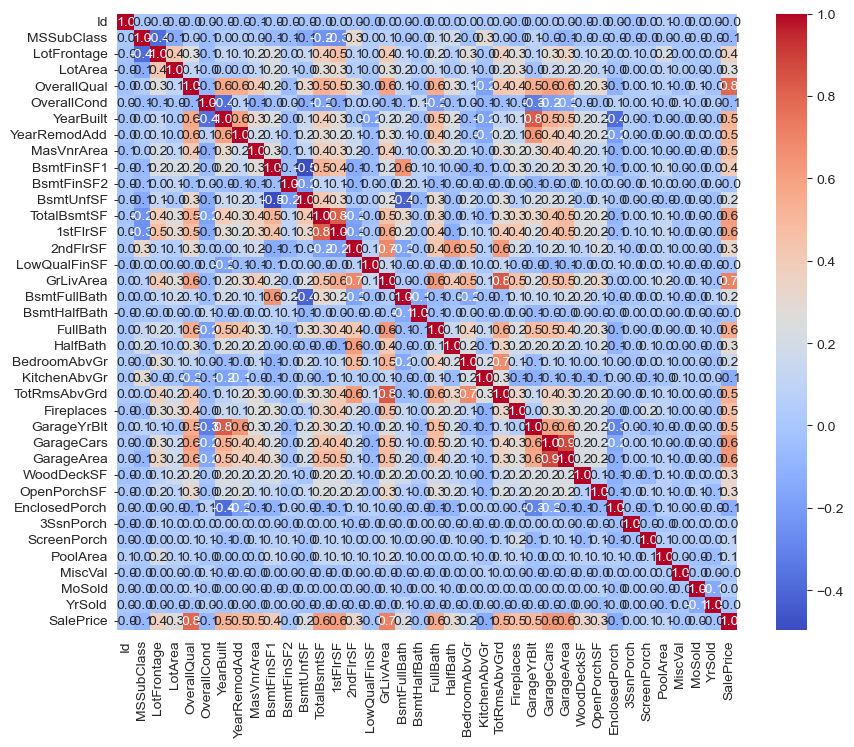

In [64]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".1f")

# 4. Separate Features and Target
separation is mandatory to prevent leakage later

In [65]:
X = df.drop(columns = ["SalePrice"], axis = 1)
y = df["SalePrice"]

# 5. Target Variable Analysis

<Axes: xlabel='SalePrice', ylabel='Count'>

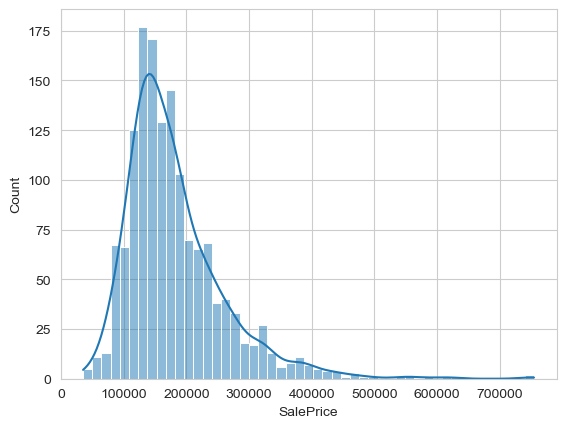

In [66]:
sns.histplot(data = y, kde = True)

#### Observation : Data distribution is Right-Skewed, long tailed of expensive houses
#### Why it matters : Linear models assume normally distributed errors, skewed targets hurts RMSE

## Applying Log Transformation

<Axes: xlabel='SalePrice', ylabel='Count'>

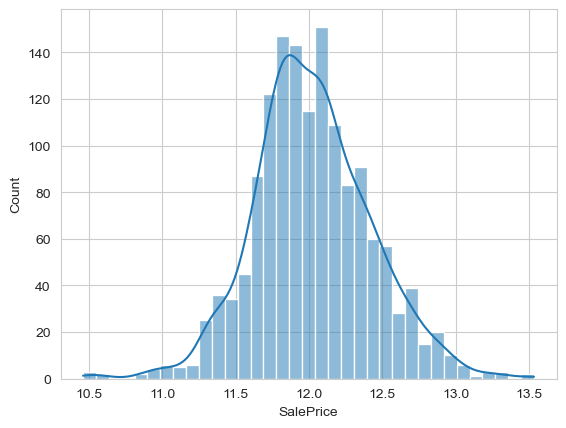

In [67]:
y_log = np.log1p(y)
sns.histplot(data = y_log, kde = True)

#### Results : Distribution is closer to normal (bell-shaped), and more stable for training
##### from now on, we model y_log, not raw price

# 6. Missing Value Analysis

In [68]:
missing = X.isna().sum().sort_values(ascending = False)
missing_percentage = (missing / len(X)) * 100
missing_percentage

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
MiscVal           0.000000
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
Length: 80, dtype: float64

#### Key Insight : Missing values are not random
examples : 
- PoolQC : missing means no pool for that property
- GarageType : missing means no garage
##### this determines how to impute

# 7. Split Numerical and Categorical Features
this split defines:
- Imputation strategy
- Encoding methods

In [69]:
num_features = X.select_dtypes(include = np.number).columns
cat_features = X.select_dtypes(include = "object").columns

# 8. Train-Validation Split (Before Engineering)
### Critical Rule : Any statistics (Mean, Encoding, Scaling) must be learned from training data only.

In [70]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size = 0.2, random_state = 42)

# 9. Handling Missing Values
### Numerical features - use Median value
### Categorical features - use Mode or most frequent

In [71]:
from sklearn.impute import SimpleImputer

In [72]:
# Numerical features imputer
num_imputer = SimpleImputer(strategy = "median")
X_train[num_features] = num_imputer.fit_transform(X_train[num_features])
X_test[num_features] = num_imputer.transform(X_test[num_features])

In [73]:
# Categorical features imputer
cat_imputer = SimpleImputer(strategy= "most_frequent")
X_train[cat_features] = cat_imputer.fit_transform(X_train[cat_features])
X_test[cat_features] = cat_imputer.transform(X_test[cat_features])

# 10. Encoding Categorical Variables

In [74]:
X_train = pd.get_dummies(X_train, drop_first = True)
X_test = pd.get_dummies(X_test, drop_first = True)

# Use align() : Training and validation must have identical columns
X_train, X_test = X_train.align(X_test, join = "left", axis = 1, fill_value = 0)

In [75]:
print(X_train.shape)
print(X_test.shape)

(1168, 243)
(292, 243)


# 11. Feature Scaling
### Required for:
- Linear Regression
- Ridge / Lasso

In [76]:
from sklearn.preprocessing import StandardScaler

In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
X_train_scaled

array([[-1.11928402, -0.8667643 , -0.01246836, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.79046412,  0.07410996, -0.50235683, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.21615189, -0.63154574, -0.14607431, ..., -0.12510865,
         0.46001984, -0.30263639],
       ...,
       [ 1.32669882, -0.8667643 , -0.45782152, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.30597137, -0.16110861, -0.6804981 , ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.93157852,  1.48542135, -0.76956873, ..., -0.12510865,
         0.46001984, -0.30263639]], shape=(1168, 243))

# 12. Baseline Model - Linear Regression
Apply Linear Regression model, finding train and test RMSE gap

In [79]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [80]:
print("y_train range:", y_train.min(), y_train.max())
print("y_test range :", y_test.min(), y_test.max())

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_train = lr.predict(X_train_scaled)
pred_test = lr.predict(X_test_scaled)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print("Train RMSE : ", rmse_train)
print("Test RMSE : ", rmse_test)

y_train range: 10.460270761075149 13.521140839642674
y_test range : 10.471978128496518 13.534474352733596
Train RMSE :  0.09199525539200487
Test RMSE :  2.7217266841230954


#### Interpretation
- Expect training RMSE < validation (test) RMSE
- Large gap = overfitting

# 13. Regularization (Rigde & Lasso)
## Ridge
Reduce Coefficient Magnitude

In [81]:
from sklearn.linear_model import Ridge

In [82]:
ridge = Ridge(alpha = 10)
ridge.fit(X_train_scaled, y_train)

pred_test = ridge.predict(X_test_scaled)
rmse_test_ridged = np.sqrt(mean_squared_error(y_test, pred_test))
print("Rigde RMSE : ", rmse_test_ridged)

Rigde RMSE :  1.1540473912175009


## Lasso
Performs Features Selection

In [83]:
from sklearn.linear_model import LassoCV

In [84]:
lasso_cv = LassoCV(
    alphas=[0.001, 0.01, 0.1],
    cv=5,
    max_iter=10000,
    random_state=42
)
lasso_cv.fit(X_train_scaled, y_train)

pred_val = lasso_cv.predict(X_test_scaled)
rmse_test_lassocv = np.sqrt(mean_squared_error(y_test, pred_val))

print("Lasso RMSE : ", rmse_test_lassocv)

Lasso RMSE :  0.1502668483894021


In [85]:
np.sum(lasso_cv.coef_ != 0)

np.int64(52)

# 14. Tree-Based Model

In [86]:
from sklearn.ensemble import RandomForestRegressor

In [87]:
rf = RandomForestRegressor(
    n_estimators = 200, 
    random_state = 42
)

In [88]:
rf.fit(X_train, y_train)
prediction = rf.predict(X_test)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, prediction))
print("Random Forest RMSE : ", rmse_test_rf)

Random Forest RMSE :  0.14958944085998988


#### Key Insight:
- No scaling required
- Handles non-linear relationships
- Harder to interpret

# 15. Final Interpretation
- Log transformation improved model stability
- Regularization reduced overfitting
- Tree models captured non-linear interactions
- Featured engineering mattered more than model choice

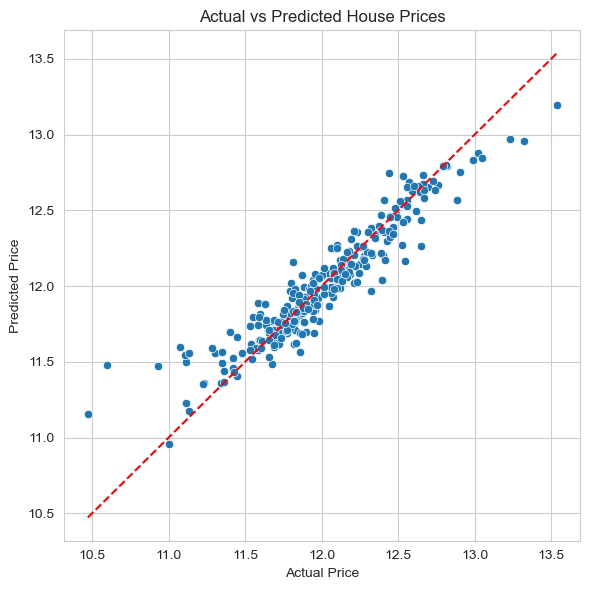

In [89]:
# Assuming:
# y_test = actual values
# y_pred = model predictions

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=prediction)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (Random Forest)")
plt.tight_layout()
plt.show()